<a href="https://colab.research.google.com/github/sahnouni150-max/-Sahnouni-Ahmed-ML-Network-Monitoring-2/blob/main/Projet1_Regression_lineaire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet 1 : Régression Linéaire (Performance Réseau)

## Objectif
Prédire le délai de transmission ou la charge réseau en utilisant un modèle de régression linéaire.

## Dataset
Pour ce projet, nous allons utiliser un jeu de données simulé de performance réseau, étant donné qu'aucun dataset spécifique de scikit-learn n'est directement disponible pour la performance réseau sans téléchargement externe.

## Travail à faire :
1.  Explorer la corrélation entre les variables (Heatmap).
2.  Entraîner un modèle de Régression Linéaire.
3.  Évaluer le modèle avec le Mean Squared Error (MSE) et le R² Score.
4.  Visualiser la droite de régression par rapport aux données réelles.

## 1. Génération et exploration du Dataset de Performance Réseau Simulé

Puisqu'un dataset spécifique n'est pas fourni, nous allons générer un jeu de données simulé pour représenter des métriques de performance réseau. Nous considérerons les variables suivantes :

*   `Trafic_Reseau_Mbps` : Le trafic réseau en Mégabits par seconde (variable explicative).
*   `Latence_ms` : La latence en millisecondes (variable explicative).
*   `Erreurs_Paquets_pourcent` : Le pourcentage d'erreurs de paquets (variable explicative).
*   `Delai_Transmission_ms` : Le délai de transmission en millisecondes (variable cible à prédire).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Génération d'un jeu de données simulé de performance réseau
np.random.seed(42)
num_samples = 200

trafic_reseau = np.random.uniform(50, 1000, num_samples) # Trafic en Mbps
latence = np.random.uniform(5, 100, num_samples) # Latence en ms
erreurs_paquets = np.random.uniform(0.1, 5, num_samples) # Pourcentage d'erreurs

# Le délai de transmission est influencé par le trafic, la latence et les erreurs
# Ajout de bruit pour simuler des conditions réelles
delai_transmission = 5 + 0.05 * trafic_reseau + 0.8 * latence + 5 * erreurs_paquets + np.random.normal(0, 10, num_samples)

data_network = pd.DataFrame({
    'Trafic_Reseau_Mbps': trafic_reseau,
    'Latence_ms': latence,
    'Erreurs_Paquets_pourcent': erreurs_paquets,
    'Delai_Transmission_ms': delai_transmission
})

print("Aperçu des données simulées de performance réseau :\n", data_network.head())
print("\nDescription des données :\n")
print(data_network.describe())


Aperçu des données simulées de performance réseau :
    Trafic_Reseau_Mbps  Latence_ms  Erreurs_Paquets_pourcent  \
0          405.813113   65.993006                  0.605307   
1          953.178591   12.993297                  4.522509   
2          745.394245   20.354728                  2.575737   
3          618.725560   90.362648                  4.149642   
4          198.217708   62.610761                  1.668243   

   Delai_Transmission_ms  
0              75.809019  
1              77.737385  
2              70.361874  
3             118.622181  
4              67.804216  

Description des données :

       Trafic_Reseau_Mbps  Latence_ms  Erreurs_Paquets_pourcent  \
count          200.000000  200.000000                200.000000   
mean           509.805922   52.915638                  2.651297   
std            280.146860   27.835113                  1.505813   
min             55.246011    5.480850                  0.153104   
25%            267.153294   29.838938      

## 2. Exploration de la corrélation entre les variables (Heatmap)

Nous allons maintenant visualiser la matrice de corrélation pour comprendre les relations entre nos variables explicatives et la variable cible `Delai_Transmission_ms`.

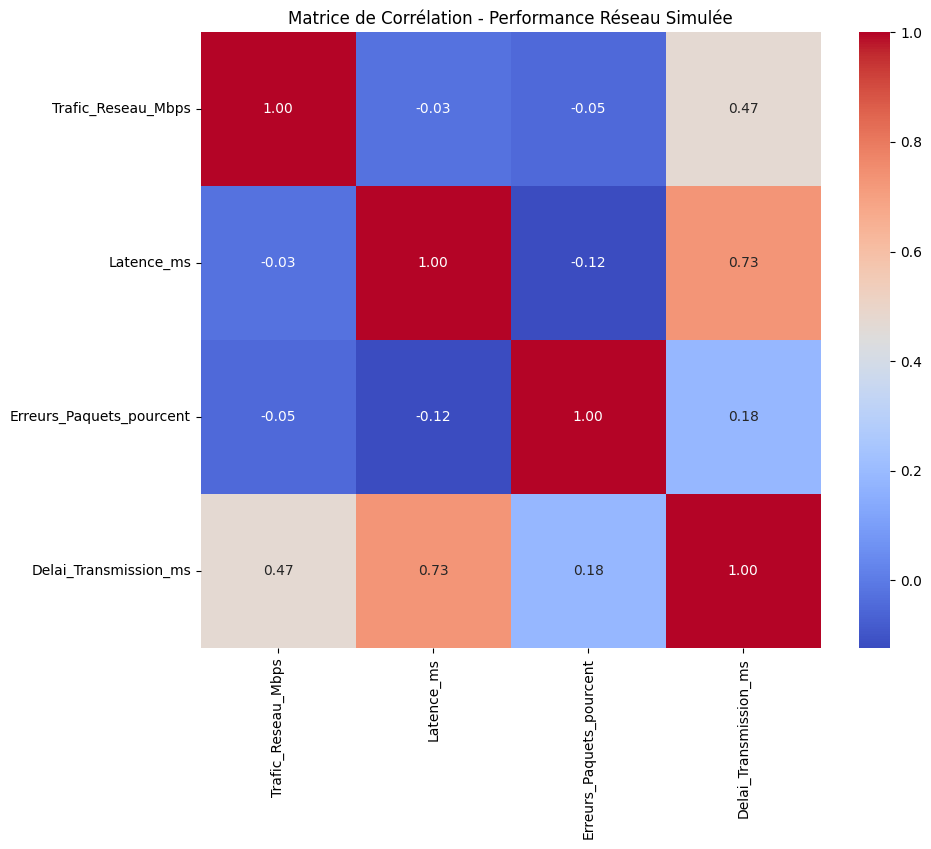

In [ ]:
# Calcul de la matrice de corrélation
correlation_matrix_network = data_network.corr()

# Affichage de la heatmap des corrélations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_network, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation - Performance Réseau Simulée')
plt.show()

## 3. Entraînement et Évaluation d'un Modèle de Régression Linéaire

Nous allons entraîner un modèle de régression linéaire pour prédire le `Delai_Transmission_ms` en utilisant toutes les autres variables comme caractéristiques. Ensuite, nous évaluerons le modèle avec le Mean Squared Error (MSE) et le R² Score.

In [ ]:
# Sélection des variables explicatives (X) et de la variable cible (y)
X = data_network[['Trafic_Reseau_Mbps', 'Latence_ms', 'Erreurs_Paquets_pourcent']]
y = data_network['Delai_Transmission_ms']

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement du modèle de régression linéaire
model_network = LinearRegression()
model_network.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred_network = model_network.predict(X_test)

# Évaluation du modèle
mse_network = mean_squared_error(y_test, y_pred_network)
r2_network = r2_score(y_test, y_pred_network)

print(f"\nMean Squared Error (MSE) pour le modèle réseau : {mse_network:.2f}")
print(f"R² Score pour le modèle réseau : {r2_network:.4f}")
print("\nCoefficients du modèle :")
for feature, coef in zip(X.columns, model_network.coef_):
    print(f"  {feature}: {coef:.3f}")
print(f"  Ordonnée à l'origine (Intercept): {model_network.intercept_:.2f}")



Mean Squared Error (MSE) pour le modèle réseau : 69.04
R² Score pour le modèle réseau : 0.8970

Coefficients du modèle :
  Trafic_Reseau_Mbps: 0.048
  Latence_ms: 0.779
  Erreurs_Paquets_pourcent: 5.777
  Ordonnée à l'origine (Intercept): 4.22


## 4. Visualisation de la droite de régression par rapport aux données réelles

Pour visualiser la droite de régression dans un espace 3D serait complexe. Au lieu de cela, nous allons visualiser les prédictions par rapport aux valeurs réelles sur un graphique de dispersion, ce qui est une approche courante pour évaluer l'ajustement du modèle.

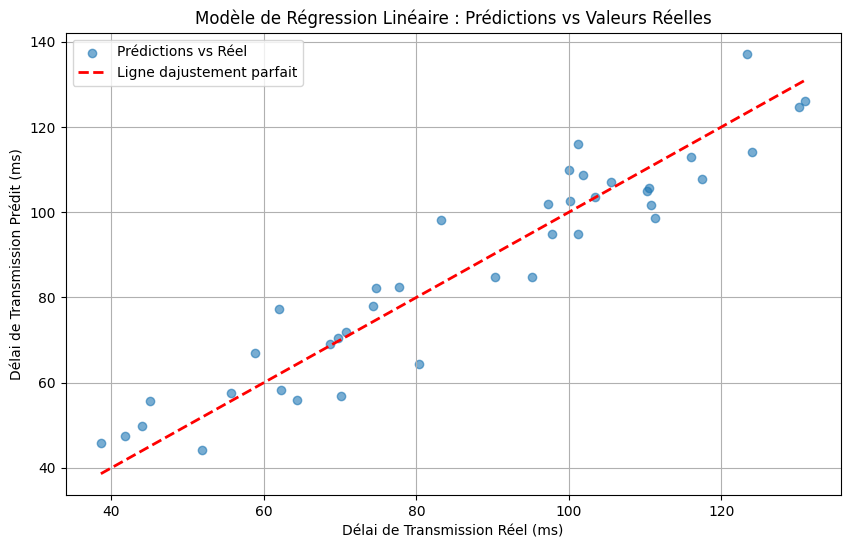


Projet 1 : Régression Linéaire (Performance Réseau) terminé avec succès !


In [ ]:
# Visualisation des prédictions vs valeurs réelles
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_network, alpha=0.6, label='Prédictions vs Réel')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ligne d''ajustement parfait')
plt.xlabel('Délai de Transmission Réel (ms)')
plt.ylabel('Délai de Transmission Prédit (ms)')
plt.title('Modèle de Régression Linéaire : Prédictions vs Valeurs Réelles')
plt.legend()
plt.grid(True)
plt.show()

print("\nProjet 1 : Régression Linéaire (Performance Réseau) terminé avec succès !")

Aperçu des données :
         age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


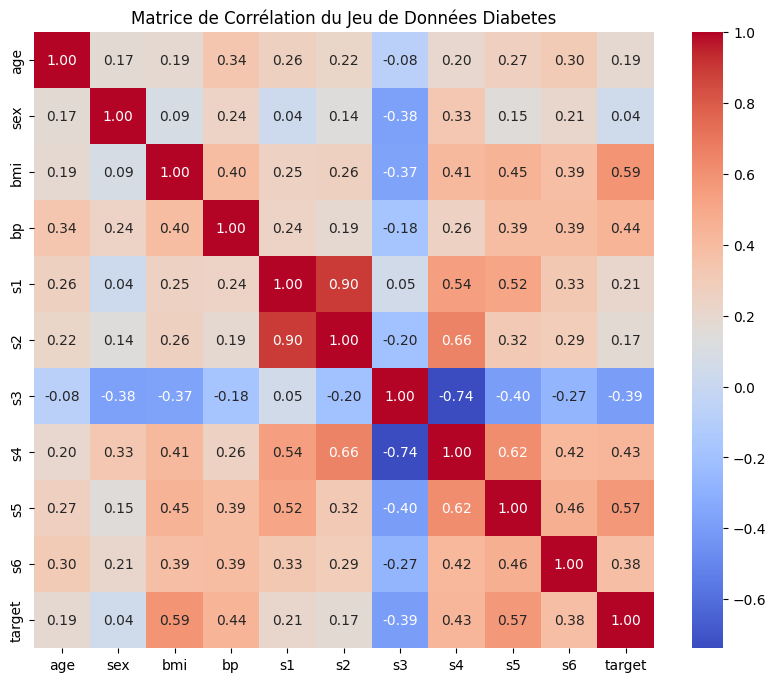

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le jeu de données Diabetes
diabetes = load_diabetes()

# Créer un DataFrame pour les caractéristiques et la cible
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='target')

# Concaténer les caractéristiques et la cible pour l'analyse de corrélation
df_diabetes = pd.concat([X, y], axis=1)

# Afficher les premières lignes du DataFrame
print("Aperçu des données :\n", df_diabetes.head())

# Calculer la matrice de corrélation
correlation_matrix = df_diabetes.corr()

# Afficher la heatmap des corrélations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation du Jeu de Données Diabetes')
plt.show()

## 1. Chargement et Aperçu du Dataset

Cette section charge le jeu de données *Diabetes* de scikit-learn et le convertit en un DataFrame Pandas pour faciliter la manipulation. Un aperçu des premières lignes est affiché, ainsi qu'une matrice de corrélation pour visualiser les relations entre les variables. La `heatmap` montre les corrélations, en mettant en évidence la relation entre `bmi` et `target`.

Aperçu des données :
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


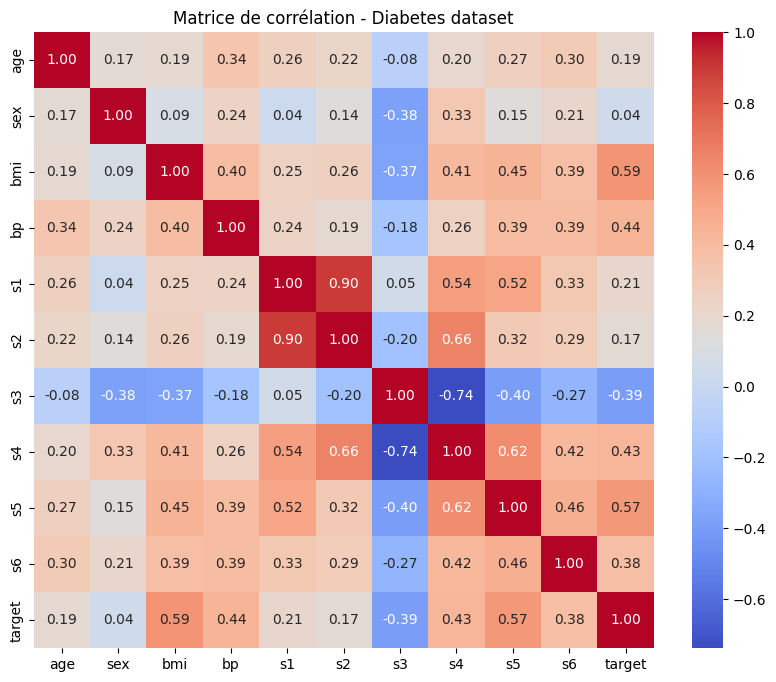


Mean Squared Error (MSE) : 4061.83
R² Score : 0.2334
Coefficient (pente) : 998.578
Ordonnée à l'origine (intercept) : 152.00


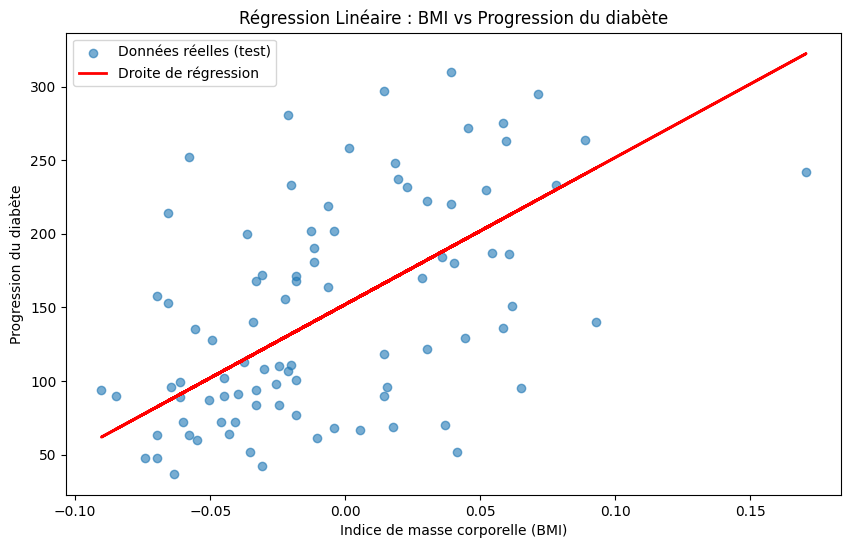


 Projet 1 terminé avec succès !


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Chargement du dataset (déjà fait dans la cellule précédente, mais repris ici pour l'autonomie de la cellule)
from sklearn.datasets import load_diabetes
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Aperçu des données :")
print(df.head())

# 2. Heatmap de corrélation (déjà fait dans la cellule précédente, mais repris ici pour l'autonomie de la cellule)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation - Diabetes dataset')
plt.show()

# 3. Sélection des variables (régression simple avec 'bmi')
X = df[['bmi']]  # Indice de masse corporelle
y = df['target']

# 4. Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entraînement
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Prédiction
y_pred = model.predict(X_test)

# 7. Évaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE) : {mse:.2f}")
print(f"R² Score : {r2:.4f}")
print(f"Coefficient (pente) : {model.coef_[0]:.3f}")
print(f"Ordonnée à l'origine (intercept) : {model.intercept_:.2f}")

# 8. Visualisation de la droite de régression
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.6, label='Données réelles (test)')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Droite de régression')
plt.xlabel('Indice de masse corporelle (BMI)')
plt.ylabel('Progression du diabète')
plt.title('Régression Linéaire : BMI vs Progression du diabète')
plt.legend()
plt.show()

print("\n Projet 1 terminé avec succès !")

## 2. Régression Linéaire Simple

Cette section met en œuvre un modèle de régression linéaire pour prédire la `target` (progression du diabète) en utilisant uniquement la caractéristique `bmi` (indice de masse corporelle).

### Étapes effectuées :

1.  **Sélection des variables :** `bmi` est choisi comme variable indépendante (X) et `target` comme variable dépendante (y).
2.  **Division des données :** Le dataset est divisé en ensembles d'entraînement (80%) et de test (20%) pour évaluer la performance du modèle sur des données non vues.
3.  **Entraînement du modèle :** Un modèle `LinearRegression` est instancié et entraîné sur les données d'entraînement.
4.  **Prédiction :** Le modèle prédit les valeurs de `target` pour l'ensemble de test.
5.  **Évaluation du modèle :** Les métriques clés, le Mean Squared Error (MSE) et le R² Score, sont calculées pour évaluer la précision et la capacité explicative du modèle.
6.  **Visualisation :** Un graphique de dispersion compare les données réelles de test aux prédictions du modèle, avec la droite de régression superposée pour illustrer l'ajustement du modèle.



> Ajouter une citation

